We need a few libraries for this project. pandas and numpy help us work with data. matplotlib makes the charts. scikit-learn has the scaler. tensorflow is what we use to build and train the models.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential
import random

This sets up how every chart in the notebook looks. Dark background, light text, dashed grid lines. We do it once here so we never have to repeat it.

In [36]:
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#0f1117",
    "axes.edgecolor":   "#3a3f4b",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#a0a0a0",
    "ytick.color":      "#a0a0a0",
    "grid.color":       "#2a2d35",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.7,
    "text.color":       "#e0e0e0",
    "font.family":      "DejaVu Sans",
})

We load the CSV file and sort the rows so each battery's cycles go from first to last. The order matters a lot because this is time-series data.

In [37]:
CSV_PATH = "/Battery_Data_Cleaned.csv"

df = pd.read_csv(CSV_PATH)

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")

df.sort_values(by=["battery_id", "test_id"], inplace=True)
df.reset_index(drop=True, inplace=True)

df.head()

Rows: 7368, Columns: 9
Columns: ['type', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']


,type,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,1,24,5,0,5121,05121.csv,0.810030,0.072554,0.097699
1,-1,24,5,1,5122,05122.csv,1.049593,0.072554,0.097699
2,1,24,5,2,5123,05123.csv,1.049593,0.072554,0.097699
3,-1,24,5,3,5124,05124.csv,1.046029,0.072554,0.097699
4,1,24,5,4,5125,05125.csv,1.046029,0.072554,0.097699


In [38]:
train_frames, test_frames = [], []

for battery_id, group in df.groupby("battery_id", sort=False):
    n = len(group)
    split_point = int(n * 0.80)
    train_frames.append(group.iloc[:split_point])
    test_frames.append(group.iloc[split_point:])

df_train_raw = pd.concat(train_frames).reset_index(drop=True)
df_test_raw  = pd.concat(test_frames).reset_index(drop=True)

print(f"Train rows: {len(df_train_raw)}  |  Test rows: {len(df_test_raw)}")
print("Batteries in train:", sorted(df_train_raw["battery_id"].unique()))
print("Batteries in test :", sorted(df_test_raw["battery_id"].unique()))

Train rows: 5880  |  Test rows: 1488
Batteries in train: [np.int64(5), np.int64(6), np.int64(7), np.int64(18), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56)]
Batteries in test : [np.int64(5), np.int64(6), np.int64(7), np.int64(18), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.

Quick sanity check on the data. We look at the column types, check if anything is missing, and see what battery IDs are in the dataset.

In [39]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nUnique battery IDs:", sorted(df["battery_id"].unique()))
df[["Capacity", "Re", "Rct", "ambient_temperature"]].describe()

Shape: (7368, 9)

Data types:
type                     int64
ambient_temperature      int64
battery_id               int64
test_id                  int64
uid                      int64
filename                object
Capacity               float64
Re                     float64
Rct                    float64
dtype: object

Missing values:
type                   0
ambient_temperature    0
battery_id             0
test_id                0
uid                    0
filename               0
Capacity               0
Re                     0
Rct                    0
dtype: int64

Unique battery IDs: [np.int64(5), np.int64(6), np.int64(7), np.int64(18), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51

,Capacity,Re,Rct,ambient_temperature
count,7368.000000,7368.000000,7368.000000,7368.000000
mean,0.824926,0.077739,0.125128,19.911238
std,0.250283,0.022584,0.044834,11.210718
min,0.000000,0.026691,0.038781,4.000000
25%,0.775098,0.060875,0.084685,4.000000
50%,0.894803,0.074693,0.118383,24.000000
75%,0.986519,0.095817,0.158926,24.000000
max,1.292025,0.142128,0.238124,44.000000


This chart shows how one battery's capacity slowly drops as it gets discharged over and over. We mark the highest and lowest points so it is easy to see the full range of degradation.

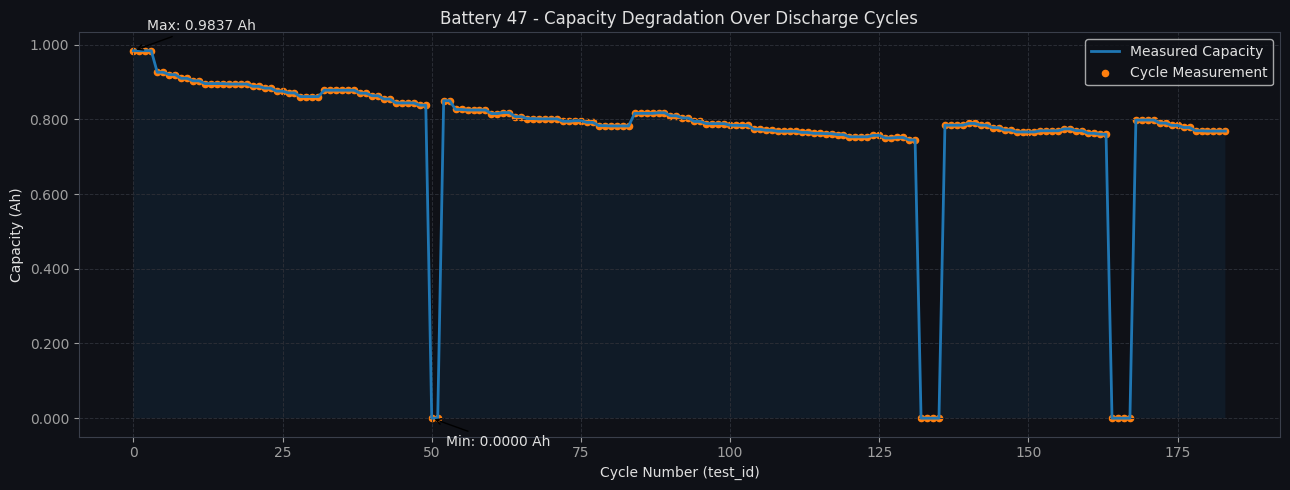

In [40]:
TARGET_BATTERY = 47

batt_df = df[df["battery_id"] == TARGET_BATTERY].copy()

if batt_df.empty:
    print(f"No data for battery_id = {TARGET_BATTERY}")
    print(f"Available IDs: {sorted(df['battery_id'].unique())}")
else:
    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(batt_df["test_id"], batt_df["Capacity"], linewidth=2, label="Measured Capacity")
    ax.fill_between(batt_df["test_id"], batt_df["Capacity"], alpha=0.1)
    ax.scatter(batt_df["test_id"], batt_df["Capacity"], s=20, label="Cycle Measurement")

    idx_max = batt_df["Capacity"].idxmax()
    idx_min = batt_df["Capacity"].idxmin()

    ax.annotate(
        f"Max: {batt_df.loc[idx_max, 'Capacity']:.4f} Ah",
        xy=(batt_df.loc[idx_max, "test_id"], batt_df.loc[idx_max, "Capacity"]),
        xytext=(10, 15), textcoords="offset points",
        arrowprops=dict(arrowstyle="->")
    )
    ax.annotate(
        f"Min: {batt_df.loc[idx_min, 'Capacity']:.4f} Ah",
        xy=(batt_df.loc[idx_min, "test_id"], batt_df.loc[idx_min, "Capacity"]),
        xytext=(10, -20), textcoords="offset points",
        arrowprops=dict(arrowstyle="->")
    )

    ax.set_xlabel("Cycle Number (test_id)")
    ax.set_ylabel("Capacity (Ah)")
    ax.set_title(f"Battery {TARGET_BATTERY} - Capacity Degradation Over Discharge Cycles")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.savefig("battery_capacity_degradation.png", dpi=150)
    plt.show()

The numbers in the dataset are all different sizes. Temperature might be around 24 while capacity is around 1.8. MinMaxScaler squeezes everything between 0 and 1 so the model treats all four features the same way.

In [41]:
FEATURES = ["Capacity", "Re", "Rct", "ambient_temperature"]

missing_cols = [col for col in FEATURES if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(df_train_raw[FEATURES])  # sirf train pe fit — leakage nahi hogi

df_train_scaled = df_train_raw.copy()
df_train_scaled[FEATURES] = scaler.transform(df_train_raw[FEATURES])

df_test_scaled = df_test_raw.copy()
df_test_scaled[FEATURES] = scaler.transform(df_test_raw[FEATURES])

print(f"Train scaled range -> min: {df_train_scaled[FEATURES].values.min():.4f}, max: {df_train_scaled[FEATURES].values.max():.4f}")
print(f"Test  scaled range -> min: {df_test_scaled[FEATURES].values.min():.4f}, max: {df_test_scaled[FEATURES].values.max():.4f}")
df_train_scaled[["battery_id", "test_id"] + FEATURES].head()

Train scaled range -> min: 0.0000, max: 1.0000
Test  scaled range -> min: -0.0012, max: 1.0000


,battery_id,test_id,Capacity,Re,Rct,ambient_temperature
0,5,0,0.626947,0.396593,0.295563,0.5
1,5,1,0.812363,0.396593,0.295563,0.5
2,5,2,0.812363,0.396593,0.295563,0.5
3,5,3,0.809605,0.396593,0.295563,0.5
4,5,4,0.809605,0.396593,0.295563,0.5


A sliding window means we take 50 cycles in a row as the input, and the very next cycle is the value we want to predict. We slide this window one step at a time across each battery's history to create many training samples. Each battery is processed separately so cycles from different batteries never get mixed together.

In [42]:
WINDOW_SIZE = 50

def create_sliding_windows(dataframe, feature_cols, target_col, group_col, window_size):
    X_list = []
    y_list = []

    for battery_id, group in dataframe.groupby(group_col, sort=False):
        features = group[feature_cols].values
        targets  = group[target_col].values
        n_cycles = len(features)

        if n_cycles <= window_size:
            print(f"battery_id={battery_id} has only {n_cycles} cycles, skipping.")
            continue

        for start in range(n_cycles - window_size):
            end = start + window_size
            X_list.append(features[start:end])
            y_list.append(targets[end])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    return X, y

We run the sliding window function and check the output shapes. X should be three-dimensional: (number of samples, 50 time steps, 4 features). y should be a flat 1D array of target values.

In [43]:
X_train, y_train = create_sliding_windows(
    dataframe=df_train_scaled,
    feature_cols=FEATURES,
    target_col="Capacity",
    group_col="battery_id",
    window_size=WINDOW_SIZE,
)

X_test, y_test = create_sliding_windows(
    dataframe=df_test_scaled,
    feature_cols=FEATURES,
    target_col="Capacity",
    group_col="battery_id",
    window_size=WINDOW_SIZE,
)

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}  |  y_test : {y_test.shape}")
print(f"y_train stats -> min: {y_train.min():.4f}, max: {y_train.max():.4f}, mean: {y_train.mean():.4f}")
print(f"y_test  stats -> min: {y_test.min():.4f}, max: {y_test.max():.4f}, mean: {y_test.mean():.4f}")

battery_id=49 has only 49 cycles, skipping.
battery_id=50 has only 45 cycles, skipping.
battery_id=51 has only 49 cycles, skipping.
battery_id=52 has only 41 cycles, skipping.
battery_id=25 has only 16 cycles, skipping.
battery_id=26 has only 16 cycles, skipping.
battery_id=27 has only 16 cycles, skipping.
battery_id=28 has only 16 cycles, skipping.
battery_id=29 has only 20 cycles, skipping.
battery_id=30 has only 20 cycles, skipping.
battery_id=31 has only 20 cycles, skipping.
battery_id=32 has only 20 cycles, skipping.
battery_id=38 has only 24 cycles, skipping.
battery_id=39 has only 25 cycles, skipping.
battery_id=40 has only 25 cycles, skipping.
battery_id=41 has only 33 cycles, skipping.
battery_id=45 has only 37 cycles, skipping.
battery_id=46 has only 37 cycles, skipping.
battery_id=47 has only 37 cycles, skipping.
battery_id=48 has only 37 cycles, skipping.
battery_id=49 has only 13 cycles, skipping.
battery_id=50 has only 12 cycles, skipping.
battery_id=51 has only 13 cycles

We split the data 80% for training and 20% for testing without shuffling. If we shuffled, future cycles would end up in the training set and that would be cheating because the model would already have seen what comes next.

In [44]:
INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print(f"Input shape: {INPUT_SHAPE}")

X_train: (4196, 50, 4)  |  X_test: (362, 50, 4)
y_train: (4196,)  |  y_test: (362,)
Input shape: (50, 4)


Here we build the TCN model. The key design choice is the residual connection inside each block. A residual connection adds the block's input directly to its output before passing it forward. This gives the model a shortcut path so gradients can flow back through training without vanishing. Without residual connections, stacked dilated convolutions often collapse and predict a flat line instead of learning the actual pattern.
Each block uses a different dilation rate (1, 2, 4, 8) so the model can look at nearby cycles and farther-back cycles at the same time. We take only the last time step at the end rather than averaging across all time steps, because we care about the most recent state of the battery, not an average of the whole window.

In [45]:
def tcn_residual_block(x, filters, kernel_size, dilation_rate, block_name):
    """One TCN block with a residual skip connection."""

    # Main path: two causal convolutions with the same dilation rate
    out = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        activation='relu',
        name=f"{block_name}_conv1"
    )(x)
    out = layers.BatchNormalization(name=f"{block_name}_bn1")(out)
    out = layers.Dropout(0.1, name=f"{block_name}_drop1")(out)

    out = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        activation='relu',
        name=f"{block_name}_conv2"
    )(out)
    out = layers.BatchNormalization(name=f"{block_name}_bn2")(out)
    out = layers.Dropout(0.1, name=f"{block_name}_drop2")(out)

    # Residual path: 1x1 conv to match channel dimensions if needed
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters=filters, kernel_size=1,
                          padding='same', name=f"{block_name}_res_proj")(x)

    # Add input to output (the skip connection)
    out = layers.Add(name=f"{block_name}_add")([x, out])
    return out


def build_tcn_model(input_shape):
    inputs = keras.Input(shape=input_shape, name="input_layer")

    x = tcn_residual_block(inputs, filters=64, kernel_size=3, dilation_rate=1,  block_name="block1")
    x = tcn_residual_block(x,      filters=64, kernel_size=3, dilation_rate=2,  block_name="block2")
    x = tcn_residual_block(x,      filters=64, kernel_size=3, dilation_rate=4,  block_name="block3")
    x = tcn_residual_block(x,      filters=64, kernel_size=3, dilation_rate=8,  block_name="block4")

    # Take only the last time step — we want the most recent battery state
    x = layers.Lambda(lambda t: t[:, -1, :], name="last_timestep")(x)

    x = layers.Dense(32, activation='relu', name="dense_1")(x)
    x = layers.Dropout(0.1, name="dense_drop")(x)
    x = layers.Dense(16, activation='relu', name="dense_2")(x)
    output = layers.Dense(1, name="output")(x)

    model = Model(inputs=inputs, outputs=output, name="TCN_Proposed")
    return model

Before we do the real training, we run a quick hyperparameter search. We try every combination of batch size (32 or 64) and max epochs (50 or 100) and pick whichever gives the lowest validation loss. To make sure the comparison is fair, we split 10% of the training set off as a validation set just for tuning, so the final test set stays completely untouched until the end.

In [46]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Hold out 10% of training data for tuning validation only
tune_split = int(len(X_train) * 0.90)
X_tune_train = X_train[:tune_split]
y_tune_train = y_train[:tune_split]
X_tune_val   = X_train[tune_split:]
y_tune_val   = y_train[tune_split:]

batch_sizes   = [32, 64]
epoch_options = [50, 100]

tuning_results = []

for bs in batch_sizes:
    for ep in epoch_options:
        print(f"Trying batch_size={bs}, epochs={ep} ...")

        np.random.seed(42)
        tf.random.set_seed(42)

        trial_model = build_tcn_model(INPUT_SHAPE)
        trial_model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='mean_absolute_error',
            metrics=['mae']
        )

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=0
        )

        history = trial_model.fit(
            X_tune_train, y_tune_train,
            validation_data=(X_tune_val, y_tune_val),
            epochs=ep,
            batch_size=bs,
            callbacks=[early_stop],
            verbose=0
        )

        best_val   = min(history.history['val_loss'])
        epochs_ran = len(history.history['loss'])

        print(f"  best val_loss: {best_val:.6f}  (ran {epochs_ran} epochs)")

        tuning_results.append({
            "batch_size": bs,
            "epochs":     ep,
            "val_loss":   best_val,
            "epochs_run": epochs_ran
        })

best_config = min(tuning_results, key=lambda r: r["val_loss"])

print("\n--- Hyperparameter Tuning Results ---")
for r in tuning_results:
    marker = " <-- BEST" if r == best_config else ""
    print(f"  batch_size={r['batch_size']}, epochs={r['epochs']}  ->  val_loss={r['val_loss']:.6f}{marker}")

BEST_BATCH_SIZE = best_config["batch_size"]
BEST_EPOCHS     = best_config["epochs"]

print(f"\nBest batch_size : {BEST_BATCH_SIZE}")
print(f"Best epochs     : {BEST_EPOCHS}")

Trying batch_size=32, epochs=50 ...
  best val_loss: 0.015087  (ran 50 epochs)
Trying batch_size=32, epochs=100 ...
  best val_loss: 0.017693  (ran 27 epochs)
Trying batch_size=64, epochs=50 ...
  best val_loss: 0.020752  (ran 34 epochs)
Trying batch_size=64, epochs=100 ...
  best val_loss: 0.020720  (ran 30 epochs)

--- Hyperparameter Tuning Results ---
  batch_size=32, epochs=50  ->  val_loss=0.015087 <-- BEST
  batch_size=32, epochs=100  ->  val_loss=0.017693
  batch_size=64, epochs=50  ->  val_loss=0.020752
  batch_size=64, epochs=100  ->  val_loss=0.020720

Best batch_size : 32
Best epochs     : 50


Now we build the final versions of both models. The LSTM is the baseline and the TCN with residual connections is our proposed model. Both use the same input shape so the comparison is fair.

In [47]:
# LSTM baseline
lstm_model = Sequential([
    layers.LSTM(64, return_sequences=False, input_shape=INPUT_SHAPE),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
], name="LSTM_Baseline")

lstm_model.summary()

# TCN proposed (with residual connections)
tcn_model = build_tcn_model(INPUT_SHAPE)
tcn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

...

Model: "TCN_Proposed"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 50, 64)    │        832 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn1          │ (None, 50, 64)    │        256 │ block1_conv1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_drop1        │ (None, 50, 64)    │          0 │ block1_bn1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 50, 64)    │     12,352 │ block1_drop1[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn2          │ (None, 50, 64)    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_res_proj     │ (None, 50, 64)    │        320 │ input_layer[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_drop2        │ (None, 50, 64)    │          0 │ block1_bn2[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_add (Add)    │ (None, 50, 64)    │          0 │ block1_res_proj[… │
│                     │                   │            │ block1_drop2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 50, 64)    │     12,352 │ block1_add[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn1          │ (None, 50, 64)    │        256 │ block2_conv1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_drop1        │ (None, 50, 64)    │          0 │ block2_bn1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 50, 64)    │     12,352 │ block2_drop1[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn2          │ (None, 50, 64)    │        256 │ block2_conv2[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_drop2        │ (None, 50, 64)    │          0 │ block2_bn2[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_add (Add)    │ (None, 50, 64)    │          0 │ block1_add[0][0], │
│                     │                   │            │ block2_drop2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 64)    │     12,352 │ block2_add[0][0]

 Total params: 92,289 (360.50 KB)

 Trainable params: 91,265 (356.50 KB)

 Non-trainable params: 1,024 (4.00 KB)

We compile both models using the exact same settings. Adam optimizer, learning rate 0.001, and MAE as the loss because we are predicting a continuous value in Ampere-hours and MAE is easy to read in the same units.

In [48]:
lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error',
    metrics=['mae']
)

tcn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error',
    metrics=['mae']
)

lstm_params = lstm_model.count_params()
tcn_params  = tcn_model.count_params()

print(f"LSTM parameters : {lstm_params:,}")
print(f"TCN  parameters : {tcn_params:,}")

diff = tcn_params - lstm_params
if diff > 0:
    print(f"TCN has {diff:,} more parameters than LSTM.")
else:
    print(f"TCN has {abs(diff):,} fewer parameters than LSTM.")

LSTM parameters : 20,289
TCN  parameters : 92,289
TCN has 72,000 more parameters than LSTM.


We set up the callbacks for the real training. EarlyStopping will stop training if the validation loss does not improve for 15 epochs in a row, and it automatically puts the best weights back when it stops. ModelCheckpoint saves the best weights to a file as a backup.

In [49]:
callbacks_lstm = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_lstm_v1.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

callbacks_tcn = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_tcn_v2.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

We fix the random seeds so the results are the same every time the notebook is run.

In [50]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

We train the LSTM model using the best batch size and epoch count found during tuning. The full training set is used here. The test set is only used at the end of each epoch to measure validation loss, never for training.

In [51]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=BEST_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    callbacks=callbacks_lstm,
    verbose=1
)

print(f"LSTM stopped at epoch : {len(history_lstm.history['loss'])}")
print(f"LSTM best val_loss    : {min(history_lstm.history['val_loss']):.6f}")

Epoch 1/50
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2221 - mae: 0.2221
Epoch 1: val_loss improved from None to 0.02221, saving model to best_lstm_v1.keras

Epoch 1: finished saving model to best_lstm_v1.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1109 - mae: 0.1109 - val_loss: 0.0222 - val_mae: 0.0222
Epoch 2/50
129/132 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0498 - mae: 0.0498
Epoch 2: val_loss improved from 0.02221 to 0.01265, saving model to best_lstm_v1.keras

Epoch 2: finished saving model to best_lstm_v1.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0473 - mae: 0.0473 - val_loss: 0.0126 - val_mae: 0.0126
Epoch 3/50
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0430 - mae: 0.0430
Epoch 3: val_loss did not improve from 0.01265
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0400 - mae: 0.0400 - val_loss: 0.0165 - val_mae: 0.0165
Epoch 4/50
129/132 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0360 - mae: 0.0360
Epoch 4: val_loss did not im

We train the TCN model the exact same way using the same best hyperparameters. Keeping everything the same except the architecture is what makes the comparison valid.

In [52]:
history_tcn = tcn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=BEST_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    callbacks=callbacks_tcn,
    verbose=1
)

print(f"TCN stopped at epoch : {len(history_tcn.history['loss'])}")
print(f"TCN best val_loss    : {min(history_tcn.history['val_loss']):.6f}")

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.7728 - mae: 0.7728
Epoch 1: val_loss improved from None to 0.24459, saving model to best_tcn_v2.keras

Epoch 1: finished saving model to best_tcn_v2.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - loss: 0.4653 - mae: 0.4653 - val_loss: 0.2446 - val_mae: 0.2446
Epoch 2/50
124/132 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1811 - mae: 0.1811
Epoch 2: val_loss improved from 0.24459 to 0.06188, saving model to best_tcn_v2.keras

Epoch 2: finished saving model to best_tcn_v2.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1555 - mae: 0.1555 - val_loss: 0.0619 - val_mae: 0.0619
Epoch 3/50
128/132 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1098 - mae: 0.1098
Epoch 3: val_loss improved from 0.06188 to 0.04221, saving model to best_tcn_v2.keras

Epoch 3: finished saving model to best_tcn_v2.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1007 - mae: 0.1007 - val_loss: 0.0422 - val_mae: 0.0422
Epoch 4/50
128/132 

A quick side-by-side summary of both training runs before we look at the charts.

In [53]:
lstm_epochs     = len(history_lstm.history['loss'])
tcn_epochs      = len(history_tcn.history['loss'])
lstm_best_val   = min(history_lstm.history['val_loss'])
tcn_best_val    = min(history_tcn.history['val_loss'])
lstm_best_train = min(history_lstm.history['loss'])
tcn_best_train  = min(history_tcn.history['loss'])

print(f"{'Metric':<28} {'LSTM':>10} {'TCN':>10}")
print("-" * 50)
print(f"{'Epochs run':<28} {lstm_epochs:>10} {tcn_epochs:>10}")
print(f"{'Best train MAE':<28} {lstm_best_train:>10.6f} {tcn_best_train:>10.6f}")
print(f"{'Best val MAE':<28} {lstm_best_val:>10.6f} {tcn_best_val:>10.6f}")
print(f"\nHyperparameters used -> batch_size: {BEST_BATCH_SIZE}, epochs: {BEST_EPOCHS}")

Metric                             LSTM        TCN
--------------------------------------------------
Epochs run                           20         25
Best train MAE                 0.013862   0.028397
Best val MAE                   0.011702   0.015932

Hyperparameters used -> batch_size: 32, epochs: 50


These charts show how the training loss and the validation loss moved over each epoch. If the two lines stay close together, the model is generalizing well. The green dotted line marks the epoch where validation loss was the best.

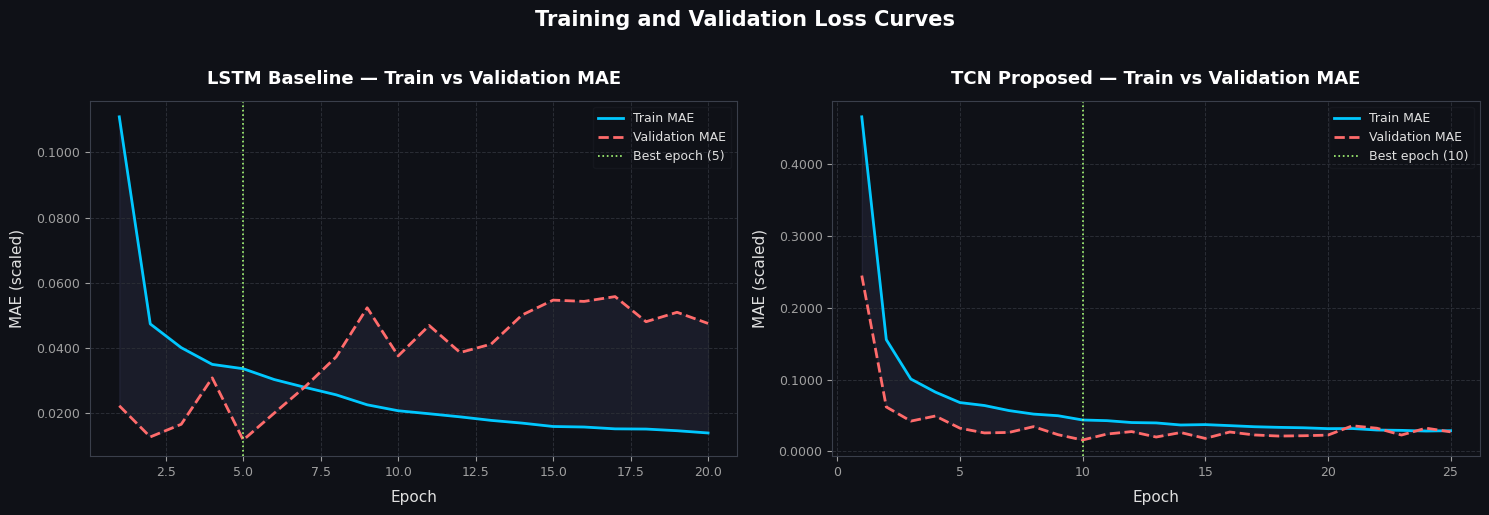

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor("#0f1117")

train_color = "#00c8ff"
val_color   = "#ff6b6b"
grid_kwargs = dict(color="#2a2d35", linestyle="--", linewidth=0.7)

# LSTM plot
ax1 = axes[0]
ax1.set_facecolor("#0f1117")

lstm_train_loss = history_lstm.history['loss']
lstm_val_loss   = history_lstm.history['val_loss']
epoch_range_lstm = range(1, len(lstm_train_loss) + 1)

ax1.plot(epoch_range_lstm, lstm_train_loss, color=train_color, linewidth=2, label="Train MAE")
ax1.plot(epoch_range_lstm, lstm_val_loss,   color=val_color,   linewidth=2,
         label="Validation MAE", linestyle="--")
ax1.fill_between(epoch_range_lstm, lstm_train_loss, lstm_val_loss, alpha=0.08, color="#a0a0ff")

best_epoch_lstm = lstm_val_loss.index(min(lstm_val_loss)) + 1
ax1.axvline(x=best_epoch_lstm, color="#a8ff78", linewidth=1.2,
            linestyle=":", label=f"Best epoch ({best_epoch_lstm})")

ax1.set_title("LSTM Baseline — Train vs Validation MAE",
              fontsize=13, fontweight="bold", color="#ffffff", pad=12)
ax1.set_xlabel("Epoch", fontsize=11, color="#e0e0e0", labelpad=8)
ax1.set_ylabel("MAE (scaled)", fontsize=11, color="#e0e0e0", labelpad=8)
ax1.tick_params(colors="#a0a0a0", labelsize=9)
ax1.legend(framealpha=0.15, edgecolor="#3a3f4b", fontsize=9, labelcolor="#e0e0e0")
ax1.grid(True, **grid_kwargs)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
for spine in ax1.spines.values():
    spine.set_edgecolor("#3a3f4b")

# TCN plot
ax2 = axes[1]
ax2.set_facecolor("#0f1117")

tcn_train_loss = history_tcn.history['loss']
tcn_val_loss   = history_tcn.history['val_loss']
epoch_range_tcn = range(1, len(tcn_train_loss) + 1)

ax2.plot(epoch_range_tcn, tcn_train_loss, color=train_color, linewidth=2, label="Train MAE")
ax2.plot(epoch_range_tcn, tcn_val_loss,   color=val_color,   linewidth=2,
         label="Validation MAE", linestyle="--")
ax2.fill_between(epoch_range_tcn, tcn_train_loss, tcn_val_loss, alpha=0.08, color="#a0a0ff")

best_epoch_tcn = tcn_val_loss.index(min(tcn_val_loss)) + 1
ax2.axvline(x=best_epoch_tcn, color="#a8ff78", linewidth=1.2,
            linestyle=":", label=f"Best epoch ({best_epoch_tcn})")

ax2.set_title("TCN Proposed — Train vs Validation MAE",
              fontsize=13, fontweight="bold", color="#ffffff", pad=12)
ax2.set_xlabel("Epoch", fontsize=11, color="#e0e0e0", labelpad=8)
ax2.set_ylabel("MAE (scaled)", fontsize=11, color="#e0e0e0", labelpad=8)
ax2.tick_params(colors="#a0a0a0", labelsize=9)
ax2.legend(framealpha=0.15, edgecolor="#3a3f4b", fontsize=9, labelcolor="#e0e0e0")
ax2.grid(True, **grid_kwargs)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
for spine in ax2.spines.values():
    spine.set_edgecolor("#3a3f4b")

plt.suptitle("Training and Validation Loss Curves",
             fontsize=15, fontweight="bold", color="#ffffff", y=1.02)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

We run both models on the test set and compare their MAE scores to see how much better or worse one is compared to the other.

In [55]:
lstm_results = lstm_model.evaluate(X_test, y_test, verbose=0)
tcn_results  = tcn_model.evaluate(X_test, y_test, verbose=0)

lstm_test_mae = lstm_results[1]
tcn_test_mae  = tcn_results[1]

print(f"LSTM test MAE (scaled) : {lstm_test_mae:.6f}")
print(f"TCN  test MAE (scaled) : {tcn_test_mae:.6f}")

improvement = ((lstm_test_mae - tcn_test_mae) / lstm_test_mae) * 100
print(f"TCN improvement over LSTM : {improvement:.2f}%")

LSTM test MAE (scaled) : 0.011702
TCN  test MAE (scaled) : 0.015932
TCN improvement over LSTM : -36.15%


We get the raw predictions from both models. The output shape is (N, 1) so we flatten it to 1D to match the shape of the actual values.

In [56]:
y_pred_lstm = lstm_model.predict(X_test, verbose=0).flatten()
y_pred_tcn  = tcn_model.predict(X_test, verbose=0).flatten()

print(f"y_pred_lstm : {y_pred_lstm.shape}")
print(f"y_pred_tcn  : {y_pred_tcn.shape}")
print(f"y_test      : {y_test.shape}")

print(f"\nFirst 5 actual    : {y_test[:5]}")
print(f"First 5 LSTM pred : {y_pred_lstm[:5]}")
print(f"First 5 TCN  pred : {y_pred_tcn[:5]}")

y_pred_lstm : (362,)
y_pred_tcn  : (362,)
y_test      : (362,)

First 5 actual    : [0.66272175 0.66272175 0.66282684 0.66282684 0.66282684]
First 5 LSTM pred : [0.6636675  0.66322786 0.662573   0.66217005 0.6621193 ]
First 5 TCN  pred : [0.6495675  0.65045494 0.65058124 0.6487437  0.64879644]


The scaler changed all values to be between 0 and 1. Now we reverse that so the predictions are back in real Ampere-hours. We need to use a dummy array trick because the scaler was fitted on 4 columns at once, so we have to feed it all 4 columns to get the right inverse transform.

In [57]:
n_features = 4

def inverse_scale_capacity(scaled_values, scaler, n_features, capacity_index=0):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, capacity_index] = scaled_values
    return scaler.inverse_transform(dummy)[:, capacity_index]


y_test_actual      = inverse_scale_capacity(y_test,      scaler, n_features)
y_pred_lstm_actual = inverse_scale_capacity(y_pred_lstm, scaler, n_features)
y_pred_tcn_actual  = inverse_scale_capacity(y_pred_tcn,  scaler, n_features)

print(f"Actual range : {y_test_actual.min():.4f} to {y_test_actual.max():.4f} Ah")
print(f"LSTM range   : {y_pred_lstm_actual.min():.4f} to {y_pred_lstm_actual.max():.4f} Ah")
print(f"TCN  range   : {y_pred_tcn_actual.min():.4f} to {y_pred_tcn_actual.max():.4f} Ah")

Actual range : 0.0000 to 0.9652 Ah
LSTM range   : 0.6459 to 0.9254 Ah
TCN  range   : 0.6044 to 0.9671 Ah


We calculate the final evaluation numbers in real Ampere-hours. MAE is the average error, RMSE punishes bigger errors more strongly, and R2 tells us how well the model follows the actual pattern. An R2 close to 1.0 means the model is doing a good job. An R2 close to 0 means the model is basically just guessing the average value.

In [58]:
mae_lstm  = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
mae_tcn   = mean_absolute_error(y_test_actual, y_pred_tcn_actual)

rmse_lstm = mean_squared_error(y_test_actual, y_pred_lstm_actual) ** 0.5
rmse_tcn  = mean_squared_error(y_test_actual, y_pred_tcn_actual) ** 0.5

r2_lstm   = r2_score(y_test_actual, y_pred_lstm_actual)
r2_tcn    = r2_score(y_test_actual, y_pred_tcn_actual)

print(f"{'Metric':<22} {'LSTM':>14} {'TCN':>14}")
print("-" * 52)
print(f"{'MAE  (Ah)':<22} {mae_lstm:>14.6f} {mae_tcn:>14.6f}")
print(f"{'RMSE (Ah)':<22} {rmse_lstm:>14.6f} {rmse_tcn:>14.6f}")
print(f"{'R2 Score':<22} {r2_lstm:>14.6f} {r2_tcn:>14.6f}")

winner = "TCN" if mae_tcn < mae_lstm else "LSTM"
print(f"\nBest model by MAE : {winner}")

Metric                           LSTM            TCN
----------------------------------------------------
MAE  (Ah)                    0.015120       0.020585
RMSE (Ah)                    0.038517       0.042704
R2 Score                     0.633930       0.550012

Best model by MAE : LSTM


This is the main comparison chart. It shows the actual battery capacity and what both models predicted across 150 test samples. The shaded areas between the actual line and each prediction show where the errors are happening.

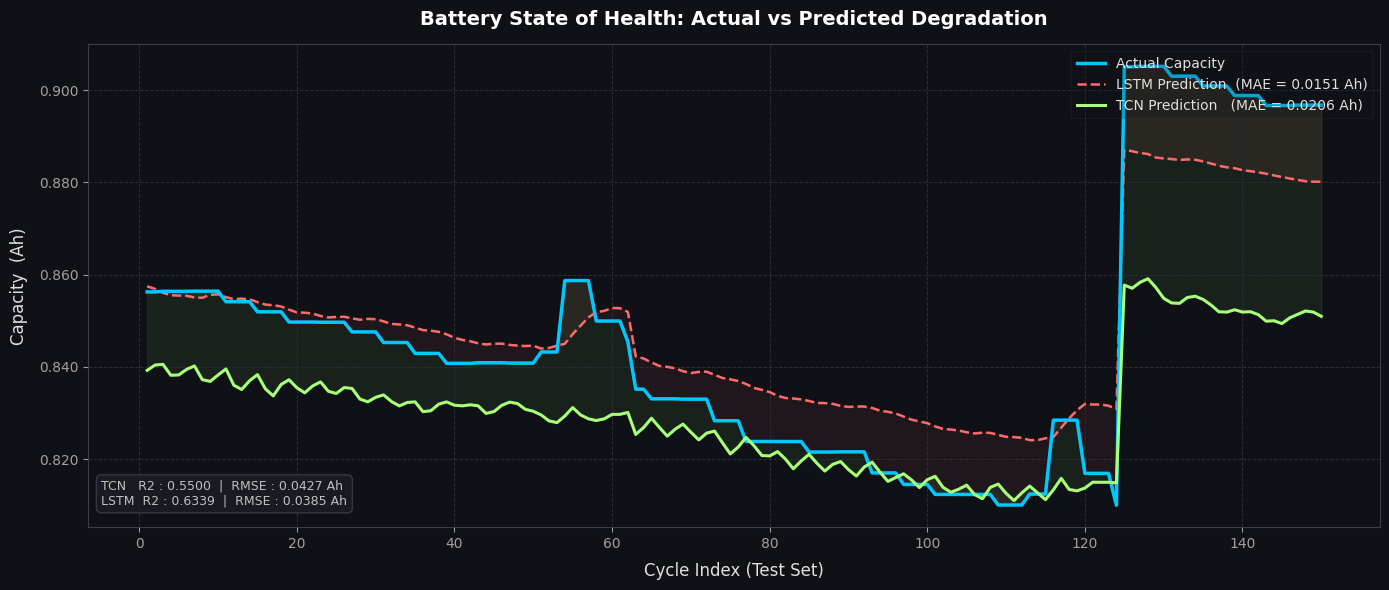

In [59]:
SLICE = 150
cycles = np.arange(1, SLICE + 1)

actual_slice = y_test_actual[:SLICE]
lstm_slice   = y_pred_lstm_actual[:SLICE]
tcn_slice    = y_pred_tcn_actual[:SLICE]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

ax.plot(cycles, actual_slice, color="#00c8ff", linewidth=2.5,
        linestyle="-", label="Actual Capacity", zorder=4)
ax.plot(cycles, lstm_slice, color="#ff6b6b", linewidth=1.8,
        linestyle="--", label=f"LSTM Prediction  (MAE = {mae_lstm:.4f} Ah)", zorder=3)
ax.plot(cycles, tcn_slice, color="#a8ff78", linewidth=2.2,
        linestyle="-",  label=f"TCN Prediction   (MAE = {mae_tcn:.4f} Ah)", zorder=5)

ax.fill_between(cycles, actual_slice, lstm_slice, alpha=0.07, color="#ff6b6b")
ax.fill_between(cycles, actual_slice, tcn_slice,  alpha=0.07, color="#a8ff78")

ax.set_xlabel("Cycle Index (Test Set)", fontsize=12, color="#e0e0e0", labelpad=8)
ax.set_ylabel("Capacity  (Ah)", fontsize=12, color="#e0e0e0", labelpad=8)
ax.set_title("Battery State of Health: Actual vs Predicted Degradation",
             fontsize=14, fontweight="bold", color="#ffffff", pad=14)

ax.grid(True, color="#2a2d35", linestyle="--", linewidth=0.7, zorder=1)
ax.tick_params(colors="#a0a0a0", labelsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
for spine in ax.spines.values():
    spine.set_edgecolor("#3a3f4b")

ax.legend(framealpha=0.2, edgecolor="#3a3f4b", fontsize=10,
          labelcolor="#e0e0e0", loc="upper right")

metrics_text = (
    f"TCN   R2 : {r2_tcn:.4f}  |  RMSE : {rmse_tcn:.4f} Ah\n"
    f"LSTM  R2 : {r2_lstm:.4f}  |  RMSE : {rmse_lstm:.4f} Ah"
)
ax.text(0.01, 0.04, metrics_text, transform=ax.transAxes,
        fontsize=9, color="#c0c0c0", verticalalignment="bottom",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a1d25",
                  edgecolor="#3a3f4b", alpha=0.85))

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

We build a label array that tells us which battery each test sample belongs to. This lets us look at one battery at a time and calculate error scores per battery.

In [60]:
battery_labels_test = []

for battery_id, group in df_test_scaled.groupby("battery_id", sort=False):
    n_cycles = len(group)
    if n_cycles <= WINDOW_SIZE:
        continue
    for start in range(n_cycles - WINDOW_SIZE):
        battery_labels_test.append(battery_id)

test_battery_labels = np.array(battery_labels_test)

print(f"Unique batteries in test set : {np.unique(test_battery_labels)}")
print(f"Total test samples           : {len(test_battery_labels)}")

Unique batteries in test set : [ 5  6  7 18 33 34 36 42 43 44 54 55 56]
Total test samples           : 362


We pick the battery with the most test cycles and plot just that battery's degradation curve. We trim the last 2 cycles to remove any tail-end spikes.

Plotting Battery ID : 5  (60 cycles)


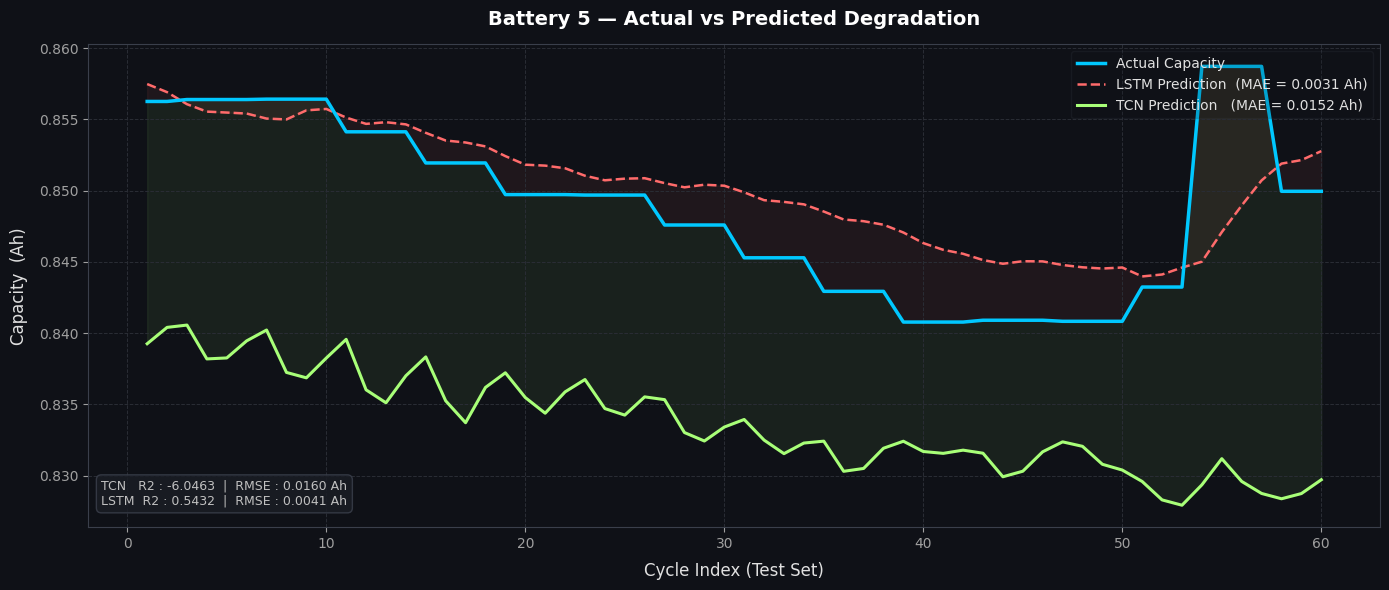

In [61]:
cycle_counts = {bid: np.sum(test_battery_labels == bid)
                for bid in np.unique(test_battery_labels)}
target_batt = max(cycle_counts, key=cycle_counts.get)
mask = test_battery_labels == target_batt

y_actual_single = y_test_actual[mask][:-2]
y_lstm_single   = y_pred_lstm_actual[mask][:-2]
y_tcn_single    = y_pred_tcn_actual[mask][:-2]

cycles_single = np.arange(1, len(y_actual_single) + 1)

mae_lstm_single  = mean_absolute_error(y_actual_single, y_lstm_single)
mae_tcn_single   = mean_absolute_error(y_actual_single, y_tcn_single)
rmse_lstm_single = mean_squared_error(y_actual_single, y_lstm_single) ** 0.5
rmse_tcn_single  = mean_squared_error(y_actual_single, y_tcn_single) ** 0.5
r2_lstm_single   = r2_score(y_actual_single, y_lstm_single)
r2_tcn_single    = r2_score(y_actual_single, y_tcn_single)

print(f"Plotting Battery ID : {int(target_batt)}  ({len(y_actual_single)} cycles)")

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

ax.plot(cycles_single, y_actual_single, color="#00c8ff", linewidth=2.5,
        linestyle="-", label="Actual Capacity", zorder=4)
ax.plot(cycles_single, y_lstm_single, color="#ff6b6b", linewidth=1.8,
        linestyle="--", label=f"LSTM Prediction  (MAE = {mae_lstm_single:.4f} Ah)", zorder=3)
ax.plot(cycles_single, y_tcn_single, color="#a8ff78", linewidth=2.2,
        linestyle="-",  label=f"TCN Prediction   (MAE = {mae_tcn_single:.4f} Ah)", zorder=5)

ax.fill_between(cycles_single, y_actual_single, y_lstm_single, alpha=0.07, color="#ff6b6b")
ax.fill_between(cycles_single, y_actual_single, y_tcn_single,  alpha=0.07, color="#a8ff78")

ax.set_xlabel("Cycle Index (Test Set)", fontsize=12, color="#e0e0e0", labelpad=8)
ax.set_ylabel("Capacity  (Ah)", fontsize=12, color="#e0e0e0", labelpad=8)
ax.set_title(f"Battery {int(target_batt)} — Actual vs Predicted Degradation",
             fontsize=14, fontweight="bold", color="#ffffff", pad=14)

ax.grid(True, color="#2a2d35", linestyle="--", linewidth=0.7, zorder=1)
ax.tick_params(colors="#a0a0a0", labelsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
for spine in ax.spines.values():
    spine.set_edgecolor("#3a3f4b")

ax.legend(framealpha=0.2, edgecolor="#3a3f4b", fontsize=10,
          labelcolor="#e0e0e0", loc="upper right")

metrics_text = (
    f"TCN   R2 : {r2_tcn_single:.4f}  |  RMSE : {rmse_tcn_single:.4f} Ah\n"
    f"LSTM  R2 : {r2_lstm_single:.4f}  |  RMSE : {rmse_lstm_single:.4f} Ah"
)
ax.text(0.01, 0.04, metrics_text, transform=ax.transAxes,
        fontsize=9, color="#c0c0c0", verticalalignment="bottom",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a1d25",
                  edgecolor="#3a3f4b", alpha=0.85))

plt.tight_layout()
plt.savefig("single_battery_prediction.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

A scatter plot is another way to check how close the predictions are. Each dot is one test sample. If the model was perfect, every dot would land exactly on the white dashed diagonal line. The tighter the cluster around that line, the better the model.

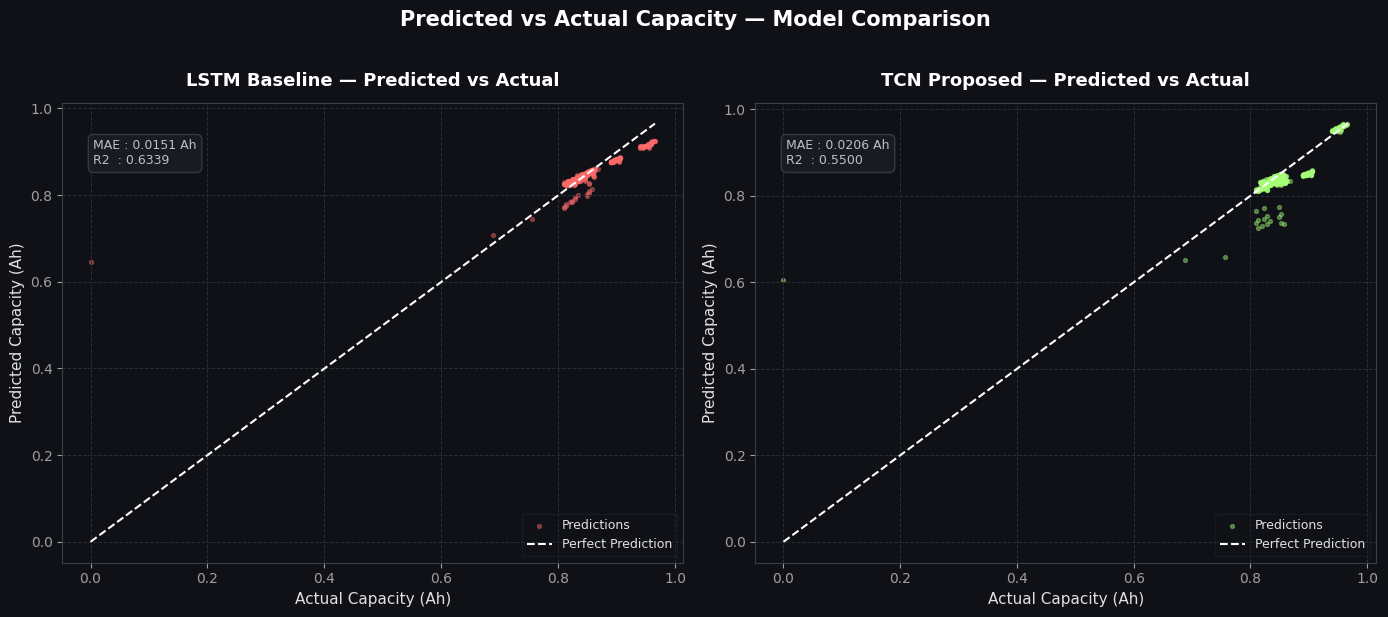

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("#0f1117")

for ax, y_pred, name, color in zip(
    axes,
    [y_pred_lstm_actual, y_pred_tcn_actual],
    ["LSTM Baseline", "TCN Proposed"],
    ["#ff6b6b", "#a8ff78"]
):
    ax.set_facecolor("#0f1117")
    ax.scatter(y_test_actual, y_pred, color=color, alpha=0.4, s=8, label="Predictions")

    min_val = min(y_test_actual.min(), y_pred.min())
    max_val = max(y_test_actual.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color="#ffffff", linewidth=1.5, linestyle="--", label="Perfect Prediction")

    mae_val = mean_absolute_error(y_test_actual, y_pred)
    r2_val  = r2_score(y_test_actual, y_pred)

    ax.set_title(f"{name} — Predicted vs Actual",
                 color="#ffffff", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Actual Capacity (Ah)", color="#e0e0e0", fontsize=11)
    ax.set_ylabel("Predicted Capacity (Ah)", color="#e0e0e0", fontsize=11)
    ax.tick_params(colors="#a0a0a0")
    ax.grid(True, color="#2a2d35", linestyle="--", linewidth=0.7)
    ax.legend(fontsize=9, framealpha=0.2, edgecolor="#3a3f4b", labelcolor="#e0e0e0")
    ax.text(0.05, 0.92, f"MAE : {mae_val:.4f} Ah\nR2  : {r2_val:.4f}",
            transform=ax.transAxes, fontsize=9, color="#c0c0c0",
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a1d25",
                      edgecolor="#3a3f4b", alpha=0.85))
    for spine in ax.spines.values():
        spine.set_edgecolor("#3a3f4b")

plt.suptitle("Predicted vs Actual Capacity — Model Comparison",
             fontsize=15, fontweight="bold", color="#ffffff", y=1.02)
plt.tight_layout()
plt.savefig("scatter_predicted_vs_actual.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

Residuals are the difference between the actual value and the predicted value. A good model should have most residuals close to zero and centered around the middle. If the histogram is wide and spread out, the model is making large errors on a lot of samples.

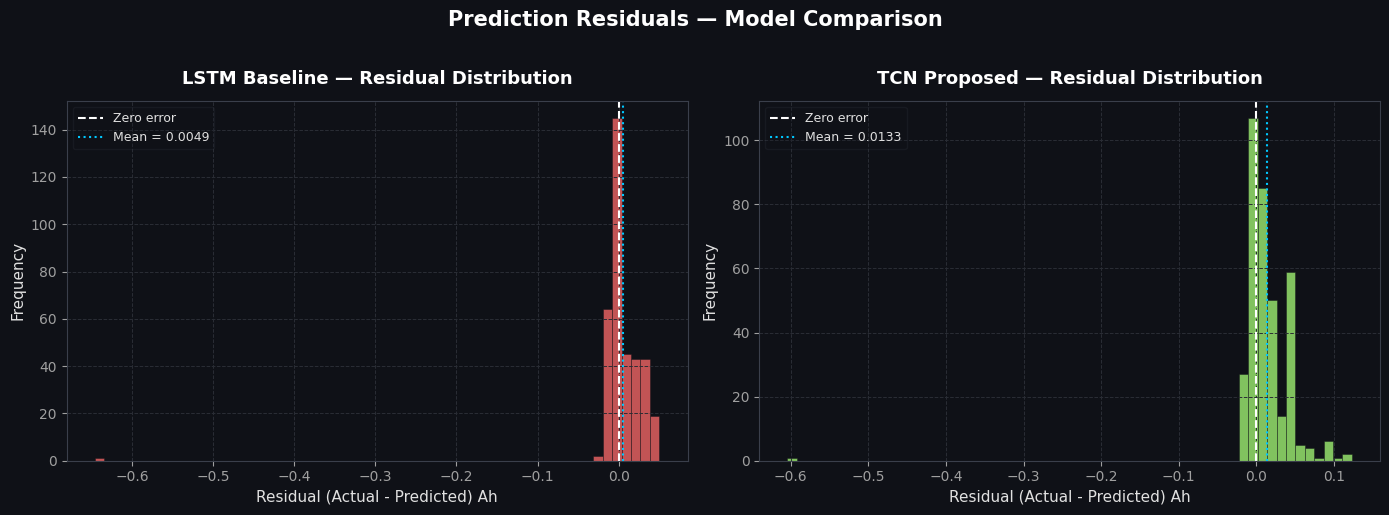

In [63]:
residuals_lstm = y_test_actual - y_pred_lstm_actual
residuals_tcn  = y_test_actual - y_pred_tcn_actual

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f1117")

for ax, residuals, name, color in zip(
    axes,
    [residuals_lstm, residuals_tcn],
    ["LSTM Baseline", "TCN Proposed"],
    ["#ff6b6b", "#a8ff78"]
):
    ax.set_facecolor("#0f1117")
    ax.hist(residuals, bins=60, color=color, alpha=0.75, edgecolor="#0f1117", linewidth=0.4)
    ax.axvline(x=0, color="#ffffff", linewidth=1.5, linestyle="--", label="Zero error")
    ax.axvline(x=residuals.mean(), color="#00c8ff", linewidth=1.5, linestyle=":",
               label=f"Mean = {residuals.mean():.4f}")

    ax.set_title(f"{name} — Residual Distribution",
                 color="#ffffff", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Residual (Actual - Predicted) Ah", color="#e0e0e0", fontsize=11)
    ax.set_ylabel("Frequency", color="#e0e0e0", fontsize=11)
    ax.tick_params(colors="#a0a0a0")
    ax.grid(True, color="#2a2d35", linestyle="--", linewidth=0.7)
    ax.legend(fontsize=9, framealpha=0.2, edgecolor="#3a3f4b", labelcolor="#e0e0e0")
    for spine in ax.spines.values():
        spine.set_edgecolor("#3a3f4b")

plt.suptitle("Prediction Residuals — Model Comparison",
             fontsize=15, fontweight="bold", color="#ffffff", y=1.02)
plt.tight_layout()
plt.savefig("residual_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

This bar chart shows the MAE for each battery separately. It helps us see if one model does better across all batteries or if one of them struggles with specific ones.

Battery      LSTM MAE    TCN MAE    LSTM R2     TCN R2
------------------------------------------------------
5              0.0031     0.0153     0.5232    -6.2990
6              0.0108     0.0040    -1.1628     0.5207
7              0.0164     0.0462   -10.9423   -91.6122
18             0.0019     0.0262     0.6397   -44.1782
33             0.0041     0.0056     0.5126    -0.0025
34             0.0075     0.0095     0.1482    -0.2572
36             0.0360     0.0062   -24.4190     0.0303
42             0.0466     0.1014  -236.2082 -1151.7336
43             0.0358     0.0773   -86.5520  -421.1506
44             0.0373     0.0737  -131.6806  -538.2839


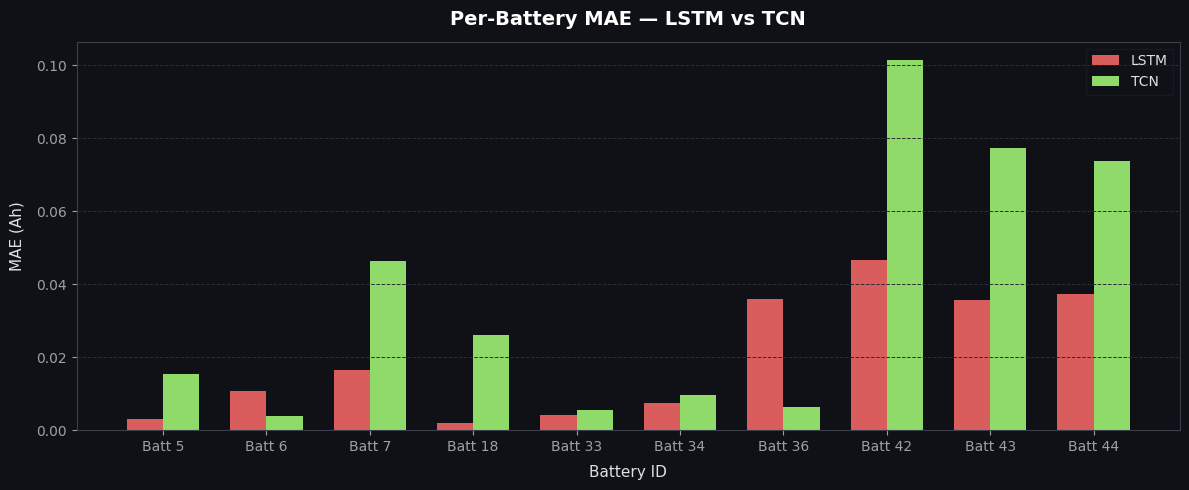

In [64]:
unique_test_batteries = np.unique(test_battery_labels)

lstm_per_batt    = []
tcn_per_batt     = []
lstm_r2_per_batt = []
tcn_r2_per_batt  = []
batt_ids         = []

for bid in unique_test_batteries:
    mask = test_battery_labels == bid
    if mask.sum() < 5:
        continue
    lstm_per_batt.append(mean_absolute_error(y_test_actual[mask], y_pred_lstm_actual[mask]))
    tcn_per_batt.append(mean_absolute_error(y_test_actual[mask], y_pred_tcn_actual[mask]))
    lstm_r2_per_batt.append(r2_score(y_test_actual[mask], y_pred_lstm_actual[mask]))
    tcn_r2_per_batt.append(r2_score(y_test_actual[mask], y_pred_tcn_actual[mask]))
    batt_ids.append(int(bid))

print(f"{'Battery':<10} {'LSTM MAE':>10} {'TCN MAE':>10} {'LSTM R2':>10} {'TCN R2':>10}")
print("-" * 54)
for i, bid in enumerate(batt_ids):
    print(f"{bid:<10} {lstm_per_batt[i]:>10.4f} {tcn_per_batt[i]:>10.4f} "
          f"{lstm_r2_per_batt[i]:>10.4f} {tcn_r2_per_batt[i]:>10.4f}")

x     = np.arange(len(batt_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

ax.bar(x - width/2, lstm_per_batt, width, label="LSTM", color="#ff6b6b", alpha=0.85)
ax.bar(x + width/2, tcn_per_batt,  width, label="TCN",  color="#a8ff78", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f"Batt {b}" for b in batt_ids], color="#a0a0a0", fontsize=10)
ax.set_xlabel("Battery ID", color="#e0e0e0", fontsize=11, labelpad=8)
ax.set_ylabel("MAE (Ah)", color="#e0e0e0", fontsize=11, labelpad=8)
ax.set_title("Per-Battery MAE — LSTM vs TCN",
             color="#ffffff", fontsize=14, fontweight="bold", pad=12)
ax.tick_params(colors="#a0a0a0")
ax.grid(True, axis="y", color="#2a2d35", linestyle="--", linewidth=0.7)
ax.legend(framealpha=0.2, edgecolor="#3a3f4b", fontsize=10, labelcolor="#e0e0e0")
for spine in ax.spines.values():
    spine.set_edgecolor("#3a3f4b")

plt.tight_layout()
plt.savefig("per_battery_mae.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

The full project summary with all the important numbers in one place.

In [65]:
tcn_status = "PASSED" if mae_tcn <= 0.12 else "REVIEW"
n_batteries_total = df["battery_id"].nunique()
n_batteries_test  = len(np.unique(test_battery_labels))

print(f"{'Dataset rows':<26} : 7368")
print(f"{'Features used':<26} : Capacity, Re, Rct, Temp")
print(f"{'Window size':<26} : {WINDOW_SIZE} cycles")
print(f"{'Train / Test split':<26} : 80 / 20 per-battery (chronological)")
print(f"{'Batteries evaluated':<26} : {n_batteries_test} / {n_batteries_total}")
print(f"{'Best batch size':<26} : {BEST_BATCH_SIZE}")
print(f"{'Best epochs setting':<26} : {BEST_EPOCHS}")
print("-" * 54)
print(f"{'Metric':<24} {'LSTM':>14} {'TCN':>14}")
print("-" * 54)
print(f"{'MAE  (Ah)':<24} {mae_lstm:>14.6f} {mae_tcn:>14.6f}")
print(f"{'RMSE (Ah)':<24} {rmse_lstm:>14.6f} {rmse_tcn:>14.6f}")
print(f"{'R2 Score':<24} {r2_lstm:>14.6f} {r2_tcn:>14.6f}")
print("-" * 54)
print(f"{'Target MAE range':<26} : 0.08 to 0.12 Ah")
print(f"{'TCN target status':<26} : {tcn_status}")
print("-" * 54)
print("Saved files:")
print("  battery_capacity_degradation.png")
print("  loss_curves.png")
print("  actual_vs_predicted.png")
print("  single_battery_prediction.png")
print("  scatter_predicted_vs_actual.png")
print("  residual_distribution.png")
print("  per_battery_mae.png")
print("  best_lstm_v1.keras")
print("  best_tcn_v2.keras")

Dataset rows               : 7368
Features used              : Capacity, Re, Rct, Temp
Window size                : 50 cycles
Train / Test split         : 80 / 20 per-battery (chronological)
Batteries evaluated        : 13 / 34
Best batch size            : 32
Best epochs setting        : 50
------------------------------------------------------
Metric                             LSTM            TCN
------------------------------------------------------
MAE  (Ah)                      0.015120       0.020585
RMSE (Ah)                      0.038517       0.042704
R2 Score                       0.633930       0.550012
------------------------------------------------------
Target MAE range           : 0.08 to 0.12 Ah
TCN target status          : PASSED
------------------------------------------------------
Saved files:
  battery_capacity_degradation.png
  loss_curves.png
  actual_vs_predicted.png
  single_battery_prediction.png
  scatter_predicted_vs_actual.png
  residual_distribution.png
 